# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *
from libraries_and_variables import *

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.parent.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data loading

In [3]:
dict_of_combs = generate_dict_of_combs(base_pairs, third_values)
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data_effect_size.sqlite'
dict_of_gdfs = {}
for i in dict_of_combs:

        df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  i
        )
        gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(df["x"], df["y"]),
                crs="EPSG:3857"
                )
        
        dict_of_gdfs[i] = gdf

In [4]:
df_results = pd.read_csv(repo_path_r_string + r'\05_results\01_data\modelling_results.csv')

In [10]:
df_results

,Unnamed: 0,effect_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,0,100.000000,treated_inner_ring,1.500000,0.952198,0.119700,1.441380,0.047432,1.434474,0.041945,1.549293,0.231114
1,1,100.000000,treated_outer_ring1,0.965972,0.692396,0.102642,1.276172,0.097738,1.032002,0.070209,1.210168,0.222402
2,2,100.000000,treated_outer_ring2,0.559725,-0.045018,0.046452,0.084665,0.032438,0.551917,0.029453,0.229281,0.200991
3,3,100.000000,treated_outer_ring3,0.176042,0.172822,0.062128,0.138559,0.047916,0.349646,0.015862,0.219097,0.173121
4,4,100.000000,treated_outer_ring4,0.023900,0.117455,0.049467,0.187316,0.035857,0.278438,0.013098,0.160509,0.162798
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,15.384615,treated_inner_ring,1.500000,0.926594,0.128361,1.245807,0.053828,1.224607,0.057213,1.227366,0.231882
4996,4996,15.384615,treated_outer_ring1,0.873396,0.291786,0.064995,0.613434,0.053931,0.814849,0.072759,0.725889,0.224548
4997,4997,15.384615,treated_outer_ring2,0.603662,0.553190,0.084900,0.886346,0.058095,0.478819,0.028570,0.895021,0.202945
4998,4998,15.384615,treated_outer_ring3,0.165481,0.064882,0.051498,0.124345,0.052581,0.299515,0.018829,0.169431,0.174775


# Data transformation

In [13]:
model_dict = {
    "mSlearn": ("att_mSlearn", "se_mSlearn"),
    "mCF": ("att_mCF", "se_mCF"),
    "dCF": ("att_dCF", "se_dCF"),
    "mDiD": ("att_mDiD", "se_mDiD"),
}

df_sig, df_flagged = compute_significance_share(
    df=df_results,
    parameter_col="ring",
    model_dict=model_dict
)

df_sig2, df_flagged2 = compute_significance_share(
    df=df_results[df_results['ring'] == 'treated_inner_ring'],
    parameter_col="effect_size",
    model_dict=model_dict
)

df_sig3, df_flagged3 = compute_significance_share(
    df=df_results[df_results['ring'] == 'treated_outer_ring3'],
    parameter_col="effect_size",
    model_dict=model_dict
)

In [14]:
df_sig3

,effect_size,n,mSlearn_sig_share,mCF_sig_share,dCF_sig_share,mDiD_sig_share
0,15.384615,100,0.64,0.70,1.0,0.43
1,16.666667,100,0.57,0.69,1.0,0.41
2,18.181818,100,0.66,0.79,1.0,0.52
3,20.000000,100,0.67,0.73,1.0,0.51
4,22.222222,100,0.56,0.66,1.0,0.46
5,25.000000,100,0.68,0.77,1.0,0.51
6,28.571429,100,0.67,0.73,1.0,0.47
7,50.000000,100,0.72,0.81,1.0,0.52
8,66.666667,100,0.57,0.66,1.0,0.44
9,100.000000,100,0.56,0.71,1.0,0.46


In [16]:
df_sig

,ring,n,mSlearn_sig_share,mCF_sig_share,dCF_sig_share,mDiD_sig_share
0,treated_inner_ring,1000,1.000,1.000,1.0,1.000
1,treated_outer_ring1,1000,0.996,0.999,1.0,1.000
2,treated_outer_ring2,1000,0.965,0.986,1.0,0.946
3,treated_outer_ring3,1000,0.630,0.725,1.0,0.473
4,treated_outer_ring4,1000,0.388,0.464,1.0,0.201


# Visualizations

## Model setup

<Axes: >

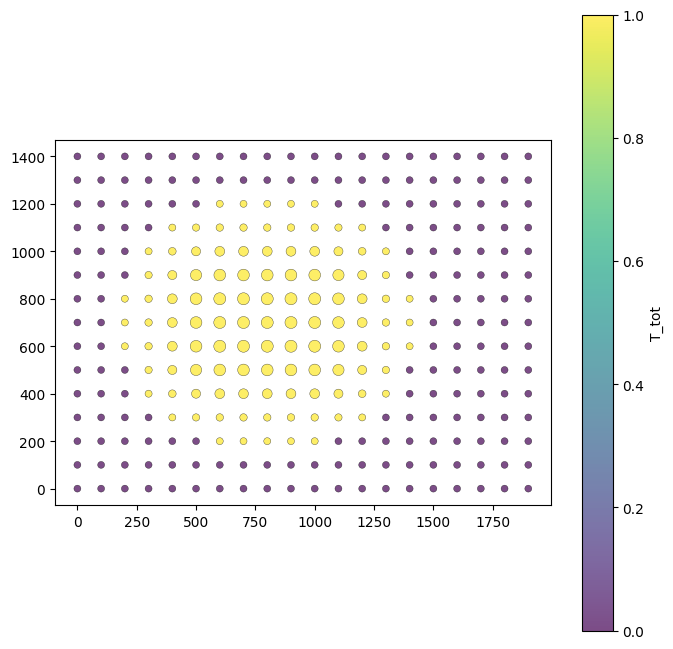

In [17]:
temp_gdf = dict_of_gdfs[list(dict_of_gdfs.keys())[0]].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

## Model parameters

C:\Users\andre\Desktop\IDS\02_VS_code\03_comparing_causal_ML_models_with_spatial_effects\01_Functions_classes_and_variables\data_exploration_functions.py:312: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


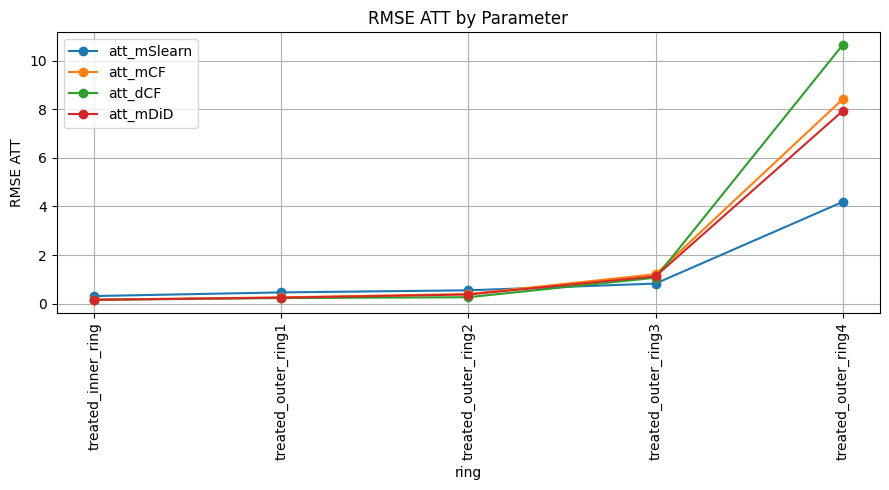

In [18]:
plot_rmse_att(
    df=df_results,
    parameter_col="ring",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD'],
    title_arg = "RMSE ATT by Parameter",
    y_axis_title = "RMSE ATT",
    rotate_x_labels=True
)

C:\Users\andre\Desktop\IDS\02_VS_code\03_comparing_causal_ML_models_with_spatial_effects\01_Functions_classes_and_variables\data_exploration_functions.py:312: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


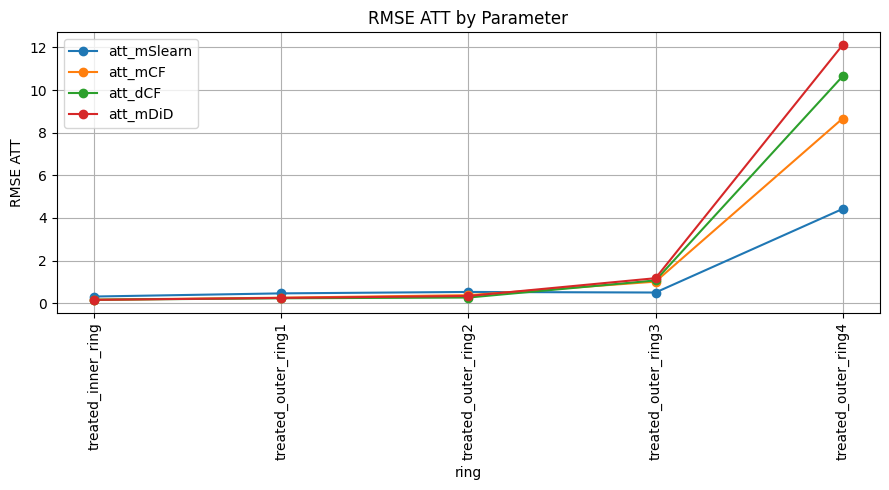

In [19]:
plot_rmse_att(
    df=df_flagged,
    parameter_col="ring",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD'],
    title_arg = "RMSE ATT by Parameter",
    y_axis_title = "RMSE ATT",
    rotate_x_labels=True
)